Selected classes:
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Name: count, dtype: int64


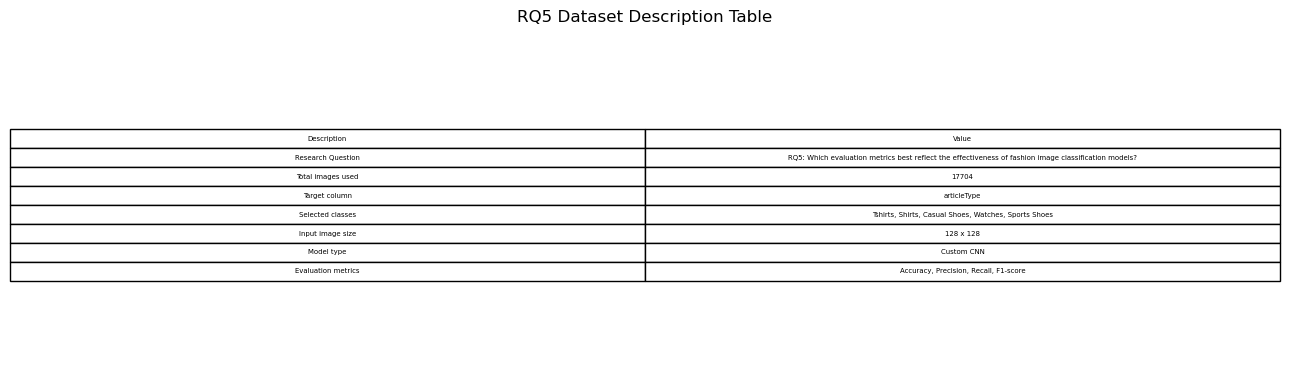

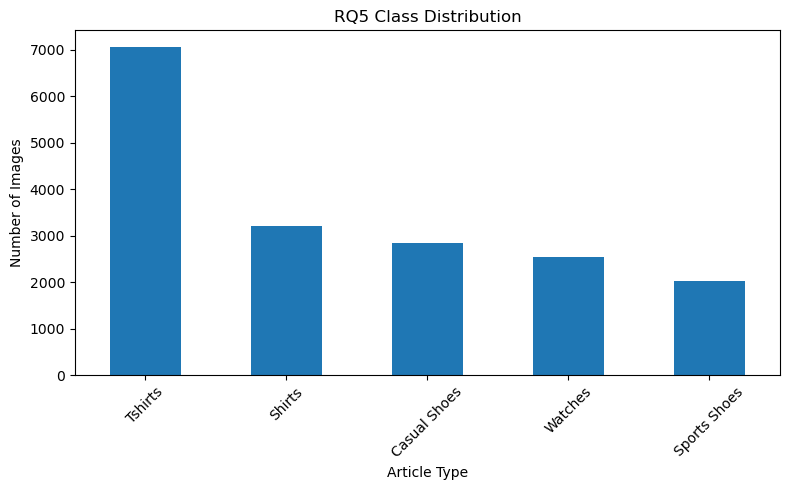

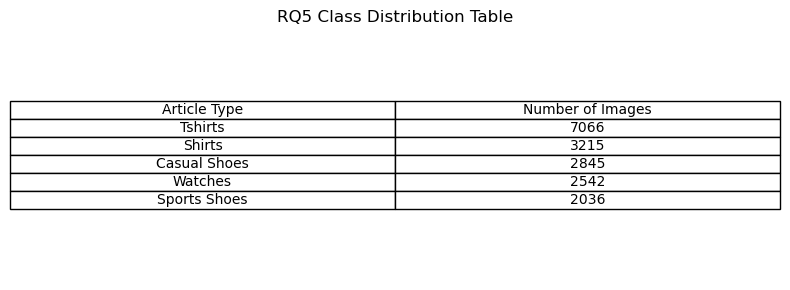

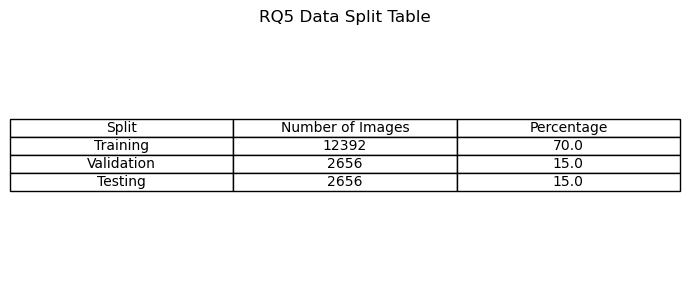

Found 12392 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.


C:\Users\hites\anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,181 (12.61 MB)

 Trainable params: 3,305,733 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 706s 2s/step - accuracy: 0.6867 - loss: 1.0675 - val_accuracy: 0.6931 - val_loss: 1.0656
Epoch 2/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.7823 - loss: 0.5415 - val_accuracy: 0.8456 - val_loss: 0.4101
Epoch 3/3
388/388 ━━━━━━━━━━━━━━━━━━━━ 674s 2s/step - accuracy: 0.8111 - loss: 0.4581 - val_accuracy: 0.7605 - val_loss: 1.4575


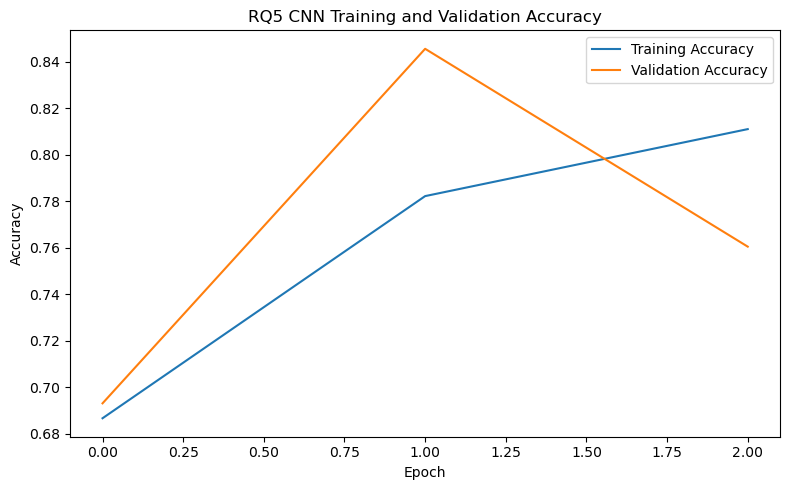

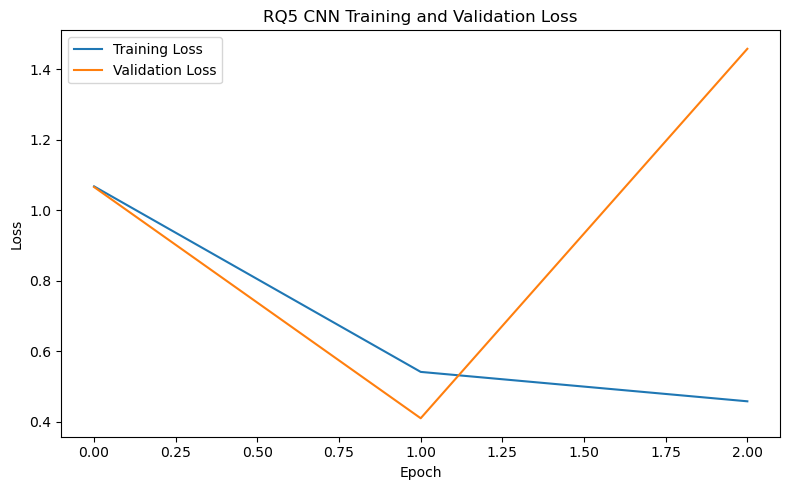

83/83 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step 
Accuracy: 0.7552710843373494
Macro Precision: 0.8263902766860417
Macro Recall: 0.7132740707851302
Macro F1-score: 0.6546954972605113
Weighted Precision: 0.8415085088209142
Weighted Recall: 0.7552710843373494
Weighted F1-score: 0.723156335144143


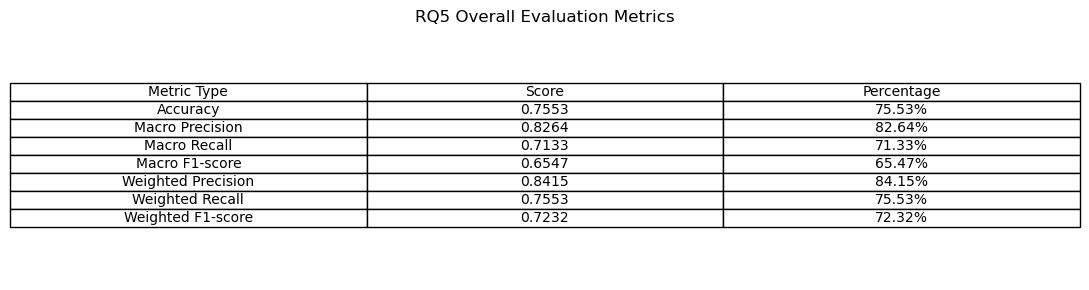

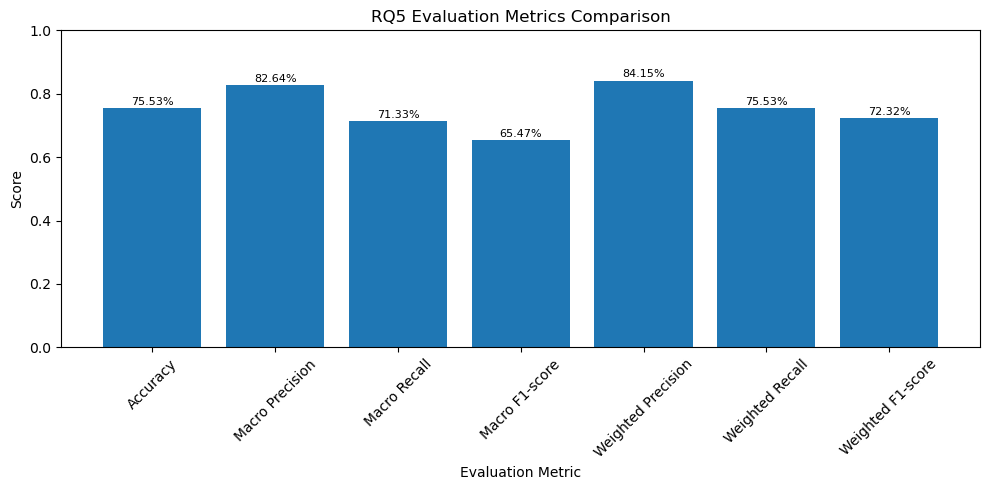

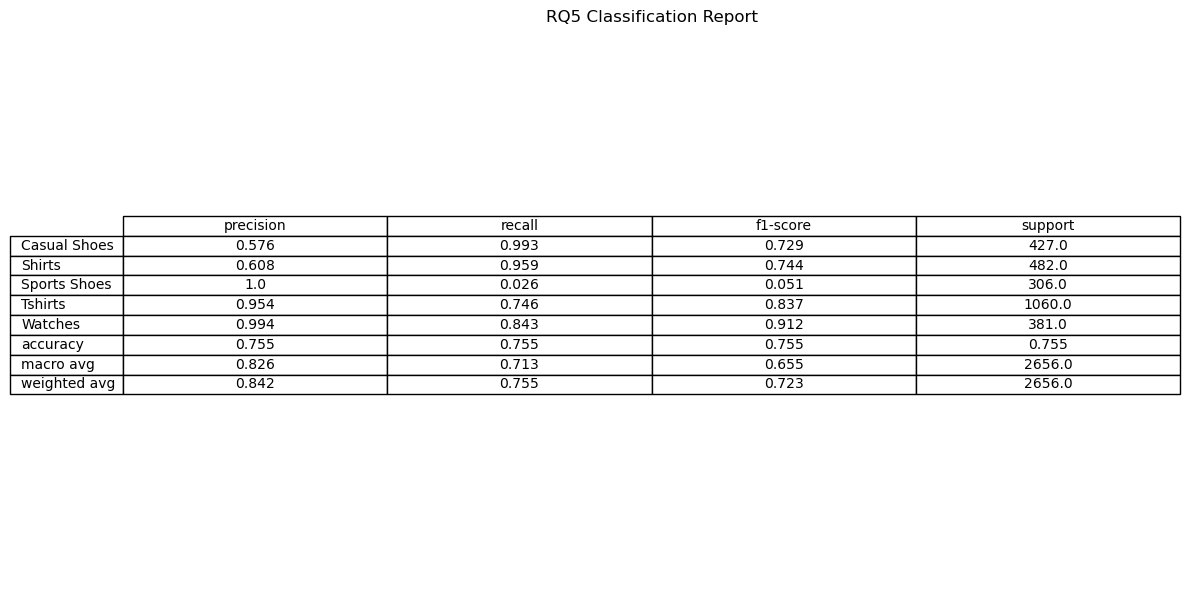

TypeError: can't multiply sequence by non-int of type 'float'

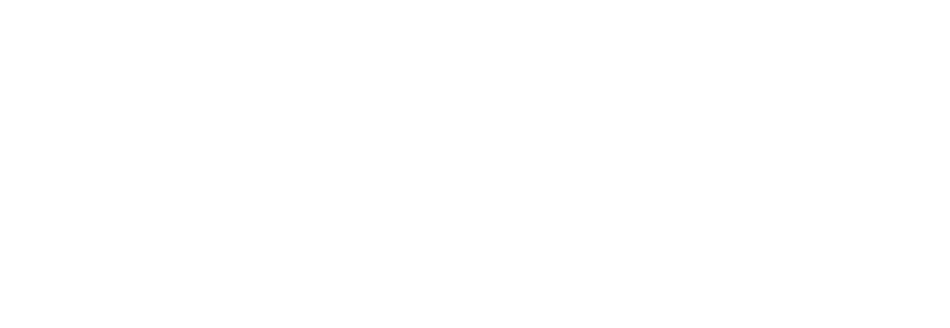

In [1]:
# RQ5: Evaluation Metrics for Fashion Image Classification Models

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


# 1. Create output folders

OUTPUT_DIR = Path("Results_RQ_Outputs")
BASE_DIR = OUTPUT_DIR / "RQ5_Evaluation_Metrics"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"
TABLE_PNG_DIR = BASE_DIR / "tables_png"
MODEL_DIR = BASE_DIR / "models"

for folder in [OUTPUT_DIR, BASE_DIR, FIG_DIR, TABLE_DIR, TABLE_PNG_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


# 2. Load CSV files

styles = pd.read_csv("styles.csv", on_bad_lines="skip")
images = pd.read_csv("images.csv")

styles["id"] = styles["id"].astype(str)
styles["filename"] = styles["id"] + ".jpg"

if "filename" in images.columns:
    df = pd.merge(styles, images, on="filename", how="inner")
else:
    df = styles.copy()


# 3. Prepare image paths

IMAGE_FOLDER = Path("images")

df["image_path"] = df["filename"].apply(lambda x: str(IMAGE_FOLDER / x))
df = df[df["image_path"].apply(os.path.exists)].copy()

if len(df) == 0:
    raise ValueError("No images found. Check that JPG files are inside the images folder.")


# 4. Select top 5 article categories

df = df.dropna(subset=["articleType"])

top_classes = df["articleType"].value_counts().head(5).index
df = df[df["articleType"].isin(top_classes)].copy()

print("Selected classes:")
print(df["articleType"].value_counts())


# 5. Dataset description table

dataset_table = pd.DataFrame({
    "Description": [
        "Research Question",
        "Total images used",
        "Target column",
        "Selected classes",
        "Input image size",
        "Model type",
        "Evaluation metrics"
    ],
    "Value": [
        "RQ5: Which evaluation metrics best reflect the effectiveness of fashion image classification models?",
        len(df),
        "articleType",
        ", ".join(top_classes),
        "128 x 128",
        "Custom CNN",
        "Accuracy, Precision, Recall, F1-score"
    ]
})

dataset_table.to_csv(TABLE_DIR / "rq5_dataset_description.csv", index=False)

plt.figure(figsize=(13, 4))
plt.axis("off")
plt.table(
    cellText=dataset_table.values,
    colLabels=dataset_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Dataset Description Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_dataset_description.png", dpi=300)
plt.show()


# 6. Class distribution

class_counts = df["articleType"].value_counts()

class_distribution = class_counts.reset_index()
class_distribution.columns = ["Article Type", "Number of Images"]
class_distribution.to_csv(TABLE_DIR / "rq5_class_distribution.csv", index=False)

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("RQ5 Class Distribution")
plt.xlabel("Article Type")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_class_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 3))
plt.axis("off")
plt.table(
    cellText=class_distribution.values,
    colLabels=class_distribution.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Class Distribution Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_class_distribution_table.png", dpi=300)
plt.show()


# 7. Train validation test split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["articleType"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["articleType"],
    random_state=42
)

split_table = pd.DataFrame({
    "Split": ["Training", "Validation", "Testing"],
    "Number of Images": [len(train_df), len(val_df), len(test_df)],
    "Percentage": [
        round(len(train_df) / len(df) * 100, 2),
        round(len(val_df) / len(df) * 100, 2),
        round(len(test_df) / len(df) * 100, 2)
    ]
})

split_table.to_csv(TABLE_DIR / "rq5_data_split.csv", index=False)

plt.figure(figsize=(7, 3))
plt.axis("off")
plt.table(
    cellText=split_table.values,
    colLabels=split_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Data Split Table")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_data_split.png", dpi=300)
plt.show()


# 8. Image generators

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="articleType",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)


# 9. Build CNN model

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


# 10. Train CNN model

history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

cnn_model.save(MODEL_DIR / "rq5_custom_cnn_model.h5")


# 11. Training curves

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("RQ5 CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_accuracy_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("RQ5 CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_loss_curve.png", dpi=300)
plt.show()


# 12. Model prediction

test_generator.reset()

pred_probs = cnn_model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes


# 13. Calculate evaluation metrics

accuracy = accuracy_score(true_classes, pred_classes)

macro_precision = precision_score(true_classes, pred_classes, average="macro", zero_division=0)
macro_recall = recall_score(true_classes, pred_classes, average="macro", zero_division=0)
macro_f1 = f1_score(true_classes, pred_classes, average="macro", zero_division=0)

weighted_precision = precision_score(true_classes, pred_classes, average="weighted", zero_division=0)
weighted_recall = recall_score(true_classes, pred_classes, average="weighted", zero_division=0)
weighted_f1 = f1_score(true_classes, pred_classes, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Macro Precision:", macro_precision)
print("Macro Recall:", macro_recall)
print("Macro F1-score:", macro_f1)
print("Weighted Precision:", weighted_precision)
print("Weighted Recall:", weighted_recall)
print("Weighted F1-score:", weighted_f1)


# 14. Overall metrics table

overall_metrics_table = pd.DataFrame({
    "Metric Type": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-score"
    ],
    "Score": [
        round(accuracy, 4),
        round(macro_precision, 4),
        round(macro_recall, 4),
        round(macro_f1, 4),
        round(weighted_precision, 4),
        round(weighted_recall, 4),
        round(weighted_f1, 4)
    ],
    "Percentage": [
        str(round(accuracy * 100, 2)) + "%",
        str(round(macro_precision * 100, 2)) + "%",
        str(round(macro_recall * 100, 2)) + "%",
        str(round(macro_f1 * 100, 2)) + "%",
        str(round(weighted_precision * 100, 2)) + "%",
        str(round(weighted_recall * 100, 2)) + "%",
        str(round(weighted_f1 * 100, 2)) + "%"
    ]
})

overall_metrics_table.to_csv(TABLE_DIR / "rq5_overall_evaluation_metrics.csv", index=False)

plt.figure(figsize=(11, 3))
plt.axis("off")
plt.table(
    cellText=overall_metrics_table.values,
    colLabels=overall_metrics_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Overall Evaluation Metrics")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_overall_evaluation_metrics.png", dpi=300)
plt.show()


# 15. Overall metrics bar chart

plt.figure(figsize=(10, 5))
plt.bar(overall_metrics_table["Metric Type"], overall_metrics_table["Score"])
plt.title("RQ5 Evaluation Metrics Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)

for i, value in enumerate(overall_metrics_table["Score"]):
    plt.text(i, value + 0.01, str(round(value * 100, 2)) + "%", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_evaluation_metrics_comparison.png", dpi=300)
plt.show()


# 16. Classification report per class

report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(TABLE_DIR / "rq5_classification_report.csv")

plt.figure(figsize=(12, 6))
plt.axis("off")
plt.table(
    cellText=np.round(report_df.values, 3),
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Classification Report")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_classification_report.png", dpi=300)
plt.show()


# 17. Per-class precision, recall, F1 table

per_class_metrics = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
per_class_metrics = per_class_metrics.reset_index()
per_class_metrics.columns = ["Class", "Precision", "Recall", "F1-score", "Support"]

per_class_metrics.to_csv(TABLE_DIR / "rq5_per_class_metrics.csv", index=False)

plt.figure(figsize=(12, 4))
plt.axis("off")
plt.table(
    cellText=np.round(per_class_metrics.values, 3),
    colLabels=per_class_metrics.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Per-Class Precision, Recall, and F1-score")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_per_class_metrics.png", dpi=300)
plt.show()


# 18. Per-class metrics grouped bar chart

x = np.arange(len(per_class_metrics["Class"]))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, per_class_metrics["Precision"], width, label="Precision")
plt.bar(x, per_class_metrics["Recall"], width, label="Recall")
plt.bar(x + width, per_class_metrics["F1-score"], width, label="F1-score")

plt.title("RQ5 Per-Class Metric Comparison")
plt.xlabel("Fashion Product Category")
plt.ylabel("Score")
plt.xticks(x, per_class_metrics["Class"], rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_per_class_metric_comparison.png", dpi=300)
plt.show()


# 19. Confusion matrix

cm = confusion_matrix(true_classes, pred_classes)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(TABLE_DIR / "rq5_confusion_matrix.csv")

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("RQ5 CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(FIG_DIR / "rq5_confusion_matrix.png", dpi=300)
plt.show()


# 20. Metric explanation table

metric_explanation = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Meaning": [
        "Shows the overall percentage of correct predictions.",
        "Shows how many predicted items for a class were actually correct.",
        "Shows how many actual items of a class were correctly identified.",
        "Combines precision and recall into one balanced score."
    ],
    "Best Use": [
        "Useful when classes are balanced.",
        "Useful when false positives are important.",
        "Useful when false negatives are important.",
        "Best overall metric when class balance and both error types matter."
    ]
})

metric_explanation.to_csv(TABLE_DIR / "rq5_metric_explanation.csv", index=False)

plt.figure(figsize=(14, 3))
plt.axis("off")
plt.table(
    cellText=metric_explanation.values,
    colLabels=metric_explanation.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Evaluation Metric Explanation")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_metric_explanation.png", dpi=300)
plt.show()


# 21. Final answer table

best_metric = "F1-score"

final_answer_table = pd.DataFrame({
    "Research Question": [
        "Which evaluation metrics best reflect the effectiveness of fashion image classification models?"
    ],
    "Best Overall Metric": [best_metric],
    "Reason": [
        "F1-score best reflects effectiveness because it balances precision and recall, especially when category performance differs."
    ],
    "Accuracy": [str(round(accuracy * 100, 2)) + "%"],
    "Macro F1-score": [str(round(macro_f1 * 100, 2)) + "%"],
    "Weighted F1-score": [str(round(weighted_f1 * 100, 2)) + "%"]
})

final_answer_table.to_csv(TABLE_DIR / "rq5_final_answer.csv", index=False)

plt.figure(figsize=(15, 3))
plt.axis("off")
plt.table(
    cellText=final_answer_table.values,
    colLabels=final_answer_table.columns,
    cellLoc="center",
    loc="center"
)
plt.title("RQ5 Final Answer")
plt.tight_layout()
plt.savefig(TABLE_PNG_DIR / "rq5_final_answer.png", dpi=300)
plt.show()


# 22. Save training history

history_table = pd.DataFrame({
    "Epoch": list(range(1, len(history.history["accuracy"]) + 1)),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

history_table.to_csv(TABLE_DIR / "rq5_training_history.csv", index=False)

print("RQ5 completed successfully.")
print("All outputs saved in:", BASE_DIR)
print("Figures saved in:", FIG_DIR)
print("CSV tables saved in:", TABLE_DIR)
print("PNG tables saved in:", TABLE_PNG_DIR)
print("Model saved in:", MODEL_DIR)